In [1]:
import numpy as np
import xarray as xr
import os 
import glob

In [2]:
#Dask parallel run
import dask
from dask.distributed import Client
import os

scheduler_file = os.path.join(os.environ["PSCRATCH"], "scheduler_jupyter.json")

dask.config.config["distributed"]["dashboard"]["link"] = "{JUPYTERHUB_SERVICE_PREFIX}proxy/{host}:{port}/status" 

client = Client(scheduler_file=scheduler_file)
client

Connection method: Scheduler file,Scheduler file: /pscratch/sd/d/dkamnani/scheduler_jupyter.json
Dashboard: /user/dkamnani/perlmutter-exclusive-node-cpu/proxy/10.249.1.77:8787/status,
Comm: tcp://10.249.1.77:8786,Workers: 0
Dashboard: /user/dkamnani/perlmutter-exclusive-node-cpu/proxy/10.249.1.77:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [3]:
#Reading AR category data
path = "/pscratch/sd/k/kquagra/Side_Jobs/Diya Collab/Categorised_ERA5_WCNA_data/"

# Match all years from 2001 to 2017
file_names = sorted(
    sum(
        [glob.glob(path + f"AR_categorization_{year}*.nc") for year in range(2001, 2018)],
        []
    )
)

In [5]:
#Opening AR Category data
ds = xr.open_mfdataset(file_names)
#print(ds)

In [6]:
#Storing AR category 
AR_event_category = ds['AR_event_category']
print(AR_event_category)

<xarray.DataArray 'AR_event_category' (time: 24712, latitude: 241,
                                       longitude: 441)>
dask.array<concatenate, shape=(24712, 241, 441), dtype=int8, chunksize=(124, 241, 441), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 60.0 59.75 59.5 59.25 ... 0.75 0.5 0.25 0.0
  * longitude  (longitude) float64 -160.0 -159.8 -159.5 ... -50.5 -50.25 -50.0
  * time       (time) datetime64[ns] 2001-01-01 ... 2017-12-31T18:00:00
Attributes:
    units:          1
    long_name:      AR Event Categories
    standard_name:  AR_event_category


In [7]:
#Reading feature co-occurence dataset 
coocurrence_path = "/pscratch/sd/d/dkamnani/Results_data/training_label_*.nc"
ds_co = xr.open_mfdataset(coocurrence_path)
print(ds_co)

<xarray.Dataset>
Dimensions:          (time: 24744, longitude: 1440, latitude: 481)
Coordinates:
  * time             (time) datetime64[ns] 2001-01-01 ... 2017-12-31T18:00:00
  * longitude        (longitude) float64 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude         (latitude) float64 60.0 59.75 59.5 ... -59.5 -59.75 -60.0
Data variables:
    feat_comb_label  (time, latitude, longitude) int8 dask.array<chunksize=(1460, 481, 1440), meta=np.ndarray>


In [8]:
#Extracting feature co occurence
ds_co = ds_co['feat_comb_label']

In [9]:
#Extractig matching time steps between above two datasets
matching_times = np.intersect1d(ds_co.time.values, AR_event_category.time.values)
ds_co = ds_co.sel(time=matching_times)
AR_event_category = AR_event_category.sel(time=matching_times)
print(ds_co)
print(AR_event_category)

<xarray.DataArray 'feat_comb_label' (time: 24620, latitude: 481, longitude: 1440)>
dask.array<getitem, shape=(24620, 481, 1440), dtype=int8, chunksize=(1460, 481, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 2001-01-01 ... 2017-12-31T18:00:00
  * longitude  (longitude) float64 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
  * latitude   (latitude) float64 60.0 59.75 59.5 59.25 ... -59.5 -59.75 -60.0
<xarray.DataArray 'AR_event_category' (time: 24620, latitude: 241,
                                       longitude: 441)>
dask.array<getitem, shape=(24620, 241, 441), dtype=int8, chunksize=(124, 241, 441), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 60.0 59.75 59.5 59.25 ... 0.75 0.5 0.25 0.0
  * longitude  (longitude) float64 -160.0 -159.8 -159.5 ... -50.5 -50.25 -50.0
  * time       (time) datetime64[ns] 2001-01-01 ... 2017-12-31T18:00:00
Attributes:
    units:          1
    long_name:      AR Event Categories
    standard

/global/homes/d/dkamnani/.conda/envs/climate_match/lib/python3.8/site-packages/xarray/core/indexing.py:1379: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


In [10]:
#Matching array dimension
ds_co = ds_co.sel(latitude=slice(60, 0))
ds_co = ds_co.assign_coords(
    longitude=(((ds_co.longitude + 180) % 360) - 180)
)

# 2. Sort longitudes (important after reassignment to avoid disordered coords)
ds_co = ds_co.sortby('longitude')

# 3. Select the desired longitude range
ds_co = ds_co.sel(longitude=slice(-160, -50))


In [11]:
print(ds_co)

<xarray.DataArray 'feat_comb_label' (time: 24620, latitude: 241, longitude: 441)>
dask.array<getitem, shape=(24620, 241, 441), dtype=int8, chunksize=(1460, 241, 441), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 2001-01-01 ... 2017-12-31T18:00:00
  * longitude  (longitude) float64 -160.0 -159.8 -159.5 ... -50.5 -50.25 -50.0
  * latitude   (latitude) float64 60.0 59.75 59.5 59.25 ... 0.75 0.5 0.25 0.0


In [12]:
#Teca data - To identify AR event 
"""
teca_path = "/global/cfs/cdirs/m4374/catalogues/raw_catalogue_files/observations/teca_era5/ERA5_BARD_AR.2005*.nc4"
teca_data = xr.open_mfdataset(teca_path)
teca_data = teca_data["ar_binary_tag"]
print(teca_data)
"""
# Update path to include all years from 2001 to 2017
teca_path = "/global/cfs/cdirs/m4374/catalogues/raw_catalogue_files/observations/teca_era5/ERA5_BARD_AR.20*.nc4"

# Open all files and subset by time
teca_data = xr.open_mfdataset(teca_path, combine='by_coords')
teca_data = teca_data["ar_binary_tag"]

# Select years 2001 to 2017
teca_data = teca_data.sel(time=slice("2001-01-01", "2017-12-31"))

print(teca_data)

<xarray.DataArray 'ar_binary_tag' (time: 149016, latitude: 721, longitude: 1440)>
dask.array<getitem, shape=(149016, 721, 1440), dtype=int8, chunksize=(744, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 2001-01-01 ... 2017-12-31T23:00:00
  * latitude   (latitude) float64 -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * longitude  (longitude) float64 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
Attributes:
    description:  binary indicator of atmospheric river
    long_name:    binary indicator of atmospheric river
    note:         derived by thresholding ar_probability >= 0.666667
    scheme:       TECA_BARD
    units:        unitless
    version:      1.0


In [13]:
#Extracting time below 
time = ds_co.time.values
teca_data = teca_data.sel(time  = time)
print(teca_data)

<xarray.DataArray 'ar_binary_tag' (time: 24620, latitude: 721, longitude: 1440)>
dask.array<getitem, shape=(24620, 721, 1440), dtype=int8, chunksize=(124, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 2001-01-01 ... 2017-12-31T18:00:00
  * latitude   (latitude) float64 -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * longitude  (longitude) float64 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
Attributes:
    description:  binary indicator of atmospheric river
    long_name:    binary indicator of atmospheric river
    note:         derived by thresholding ar_probability >= 0.666667
    scheme:       TECA_BARD
    units:        unitless
    version:      1.0


In [14]:
teca_data = teca_data.sel(latitude=slice(0, 60))
teca_data = teca_data.sortby('latitude', ascending = False)

teca_data = teca_data.assign_coords(longitude=(((teca_data.longitude + 180) % 360) - 180))
# 2. Sort longitudes (important after reassignment to avoid disordered coords)
teca_data = teca_data.sortby('longitude')

# 3. Select the desired longitude range
teca_data = teca_data.sel(longitude=slice(-160, -50))
print(teca_data)

<xarray.DataArray 'ar_binary_tag' (time: 24620, latitude: 241, longitude: 441)>
dask.array<getitem, shape=(24620, 241, 441), dtype=int8, chunksize=(124, 241, 441), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 2001-01-01 ... 2017-12-31T18:00:00
  * latitude   (latitude) float64 60.0 59.75 59.5 59.25 ... 0.75 0.5 0.25 0.0
  * longitude  (longitude) float64 -160.0 -159.8 -159.5 ... -50.5 -50.25 -50.0
Attributes:
    description:  binary indicator of atmospheric river
    long_name:    binary indicator of atmospheric river
    note:         derived by thresholding ar_probability >= 0.666667
    scheme:       TECA_BARD
    units:        unitless
    version:      1.0


In [15]:
# Remap categories: 6 and 7 -> 5
AR_event_category_remap = xr.where(AR_event_category.isin([6, 7]), 5, AR_event_category)

In [ ]:
#Calculating for each AR category, the percentage distribution of co-occurring categories only at locations/times where an AR event happens
import numpy as np
import xarray as xr
import pandas as pd

# Ensure same shape and alignment
assert ds_co.shape == AR_event_category_remap.shape == teca_data.shape

# Get unique AR and co-occurrence categories
ar_categories = np.unique(AR_event_category_remap.values)
ar_categories = ar_categories[ar_categories != 0]
print(ar_categories)
co_categories = np.arange(0, 17)  # Assuming categories 1 to 16

# Prepare results
result = pd.DataFrame(index=co_categories, columns=ar_categories, dtype=float)

# Loop over AR categories
for ar_cat in ar_categories:
    print(ar_cat)
    if ar_cat == 0:
        continue
    else:# Mask where Ar_event_category == ar_cat
        mask = (AR_event_category_remap == ar_cat) & (teca_data == 1)
    
    # Extract corresponding ds_co values
    ds_vals = ds_co.where(mask).values.flatten()
    ds_vals = ds_vals[~np.isnan(ds_vals)]  # Remove NaNs
    ds_vals = ds_vals[ds_vals != 0] 
    
    # Count total
    total = len(ds_vals)
    
    # Count each co-occurrence category
    for co_cat in co_categories:
        count = np.sum(ds_vals == co_cat)
        percent = (count / total * 100) if total > 0 else 0
        result.loc[co_cat, ar_cat] = percent

[1 2 3 4 5]
1


In [ ]:
print(result.sum(axis=0))

In [ ]:
#plotting the annual result
import matplotlib.pyplot as plt

# Label index mapping
label_index = {
    1: 'AR',
    2: 'Front',
    3: 'MCS',
    4: 'LPS',
    5: 'AR + Front',
    6: 'AR + MCS',
    7: 'AR + LPS',
    8: 'Front + MCS',
    9: 'Front + LPS',
    10: 'MCS + LPS',
    11: 'AR + Front + MCS',
    12: 'AR + Front + LPS',
    13: 'AR + MCS + LPS',
    14: 'Front + MCS + LPS',
    15: 'All'
}

# Only convert columns to int if needed (e.g., AR categories like 1, 2, 3, ...)
try:
    result.columns = result.columns.astype(int)
except ValueError:
    pass  # Already properly formatted

# Rename index using label mapping (assumes index has integers 1–15)
if result.index.dtype != 'O':  # Object type means already strings like 'AR'
    result = result.rename(index=label_index)

# Sort columns numerically
result = result.sort_index(axis=1)

# Remove co-occurrence categories (rows) with all 0 or NaN
nonzero_mask = result.notna().any(axis=1) & (result != 0).any(axis=1)
filtered_result = result.loc[nonzero_mask]

# Plot
ax = filtered_result.T.plot(kind='bar', stacked=True, figsize=(12, 6))

ax.set_xlabel("AR Event Category")
ax.set_ylabel("Percentage of Co-Occurrence Category")
ax.set_title("Stacked Distribution of Co-Occurrence Categories per AR Category")
ax.legend(title="Co-Occurrence Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
result.to_csv("AR_cooccurrence_percentages.csv")

## Doing the calculation seasonally

In [19]:
# Assuming 'time' coordinate exists in AR_event_category
import pandas as pd
time_index = pd.DatetimeIndex(AR_event_category_remap.time.values)

# Create seasonal masks
DJF_mask = time_index.month.isin([12, 1, 2])
MAM_mask = time_index.month.isin([3, 4, 5])
JJA_mask = time_index.month.isin([6, 7, 8])
SON_mask = time_index.month.isin([9, 10, 11])
seasons = {"DJF": DJF_mask, "MAM": MAM_mask, "JJA": JJA_mask, "SON": SON_mask}


In [20]:
import numpy as np
import xarray as xr
import pandas as pd

# Example: Define season mapping for each timestep
# Adjust based on your dataset
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

# Create season array from time dimension
seasons = [get_season(pd.to_datetime(t).month) for t in ds_co.time.values]

# Prepare long-format DataFrame
all_results = []

# Loop over seasons
for season in ['Winter', 'Spring', 'Summer', 'Fall']:
    # Select seasonal data
    print(season)
    season_mask = [s == season for s in seasons]
    ds_co_season = ds_co.isel(time=season_mask)
    AR_event_category_season = AR_event_category_remap.isel(time=season_mask)
    teca_data_season = teca_data.isel(time=season_mask)

    # Multiply AR_event_category by teca_data to mask automatically
    masked_AR = AR_event_category_season * teca_data_season

    # Unique AR categories (excluding 0)
    ar_categories = np.unique(masked_AR.values)
    ar_categories = ar_categories[ar_categories != 0]
    print(ar_categories)

    co_categories = np.arange(0, 17)  # assuming categories 1 to 16

    # Calculate percentages for each AR & co-occurrence category
    for ar_cat in ar_categories:
        print(ar_cat)
        mask = masked_AR == ar_cat
        ds_vals = ds_co_season.where(mask).values.flatten()
        ds_vals = ds_vals[~np.isnan(ds_vals)]
        ds_vals = ds_vals[ds_vals != 0] 

        total = len(ds_vals)
        for co_cat in co_categories:
            count = np.sum(ds_vals == co_cat)
            percent = (count / total * 100) if total > 0 else 0
            all_results.append([season, co_cat, ar_cat, percent])

# Create combined DataFrame
result_df = pd.DataFrame(all_results, columns=['Season', 'CoCategory', 'ARCategory', 'Percent'])


Winter
[1 2 3 4 5]
1
2
3
4
5
Spring
[1 2 3 4 5]
1
2
3
4
5
Summer
[1 2 3 4 5]
1
2
3
4
5
Fall
[1 2 3 4 5]
1
2
3
4
5


In [21]:
print(result_df)

     Season  CoCategory  ARCategory   Percent
0    Winter           0           1  0.000000
1    Winter           1           1  9.919116
2    Winter           2           1  0.000000
3    Winter           3           1  0.000000
4    Winter           4           1  0.000000
..      ...         ...         ...       ...
335    Fall          12           5  2.948705
336    Fall          13           5  2.456835
337    Fall          14           5  0.000000
338    Fall          15           5  1.465566
339    Fall          16           5  0.000000

[340 rows x 4 columns]


In [22]:
print(result.sum(axis=0))

1    100.0
2    100.0
3    100.0
4    100.0
5    100.0
dtype: float64


In [23]:
result_df.to_csv("results_seasons.csv", index=False)

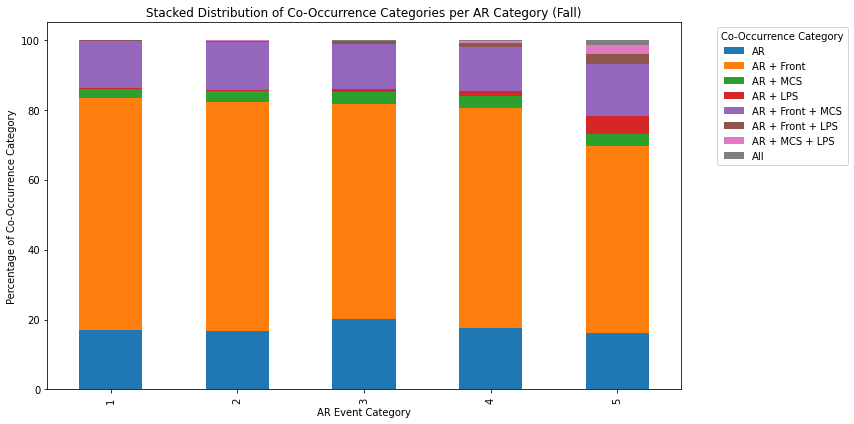

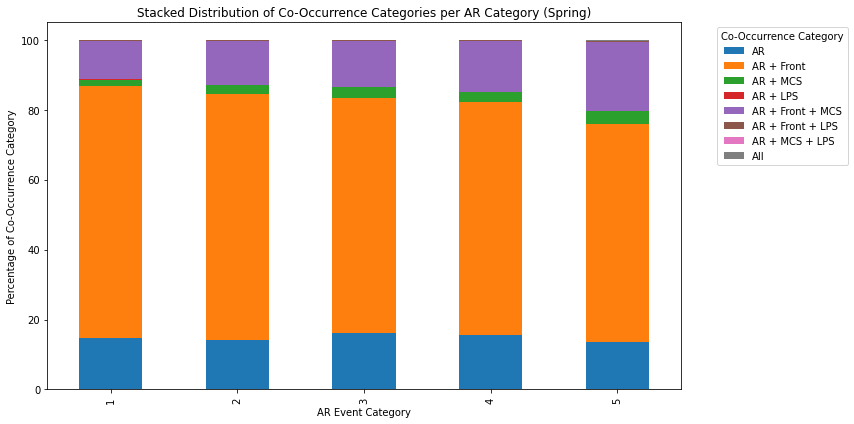

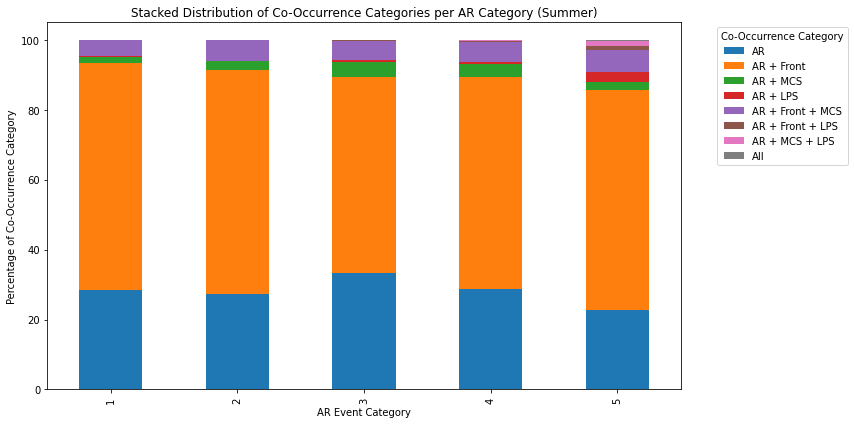

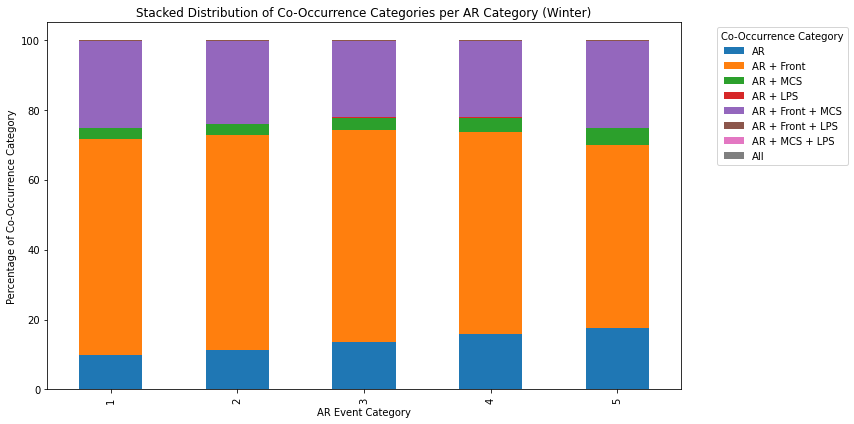

In [25]:
#Plotting the seasonal 
import matplotlib.pyplot as plt
import pandas as pd

# Define label mapping
label_index = {
    1: 'AR', 2: 'Front', 3: 'MCS', 4: 'LPS',
    5: 'AR + Front', 6: 'AR + MCS', 7: 'AR + LPS',
    8: 'Front + MCS', 9: 'Front + LPS',
    10: 'MCS + LPS', 11: 'AR + Front + MCS',
    12: 'AR + Front + LPS', 13: 'AR + MCS + LPS',
    14: 'Front + MCS + LPS', 15: 'All'
}

# Loop over each season and plot separately
for season, df_season in result_df.groupby("Season"):
    # Pivot for stacked bar plotting
    pivot_df = df_season.pivot(
        index="CoCategory",
        columns="ARCategory",
        values="Percent"
    )

    # Rename CoCategory using label_index
    pivot_df = pivot_df.rename(index=label_index)

    # Remove rows that are all 0 or NaN
    nonzero_mask = pivot_df.notna().any(axis=1) & (pivot_df != 0).any(axis=1)
    pivot_df = pivot_df.loc[nonzero_mask]

    # Plot stacked bar chart
    ax = pivot_df.T.plot(kind="bar", stacked=True, figsize=(12, 6))

    ax.set_xlabel("AR Event Category")
    ax.set_ylabel("Percentage of Co-Occurrence Category")
    ax.set_title(f"Stacked Distribution of Co-Occurrence Categories per AR Category ({season})")
    ax.legend(title="Co-Occurrence Category", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


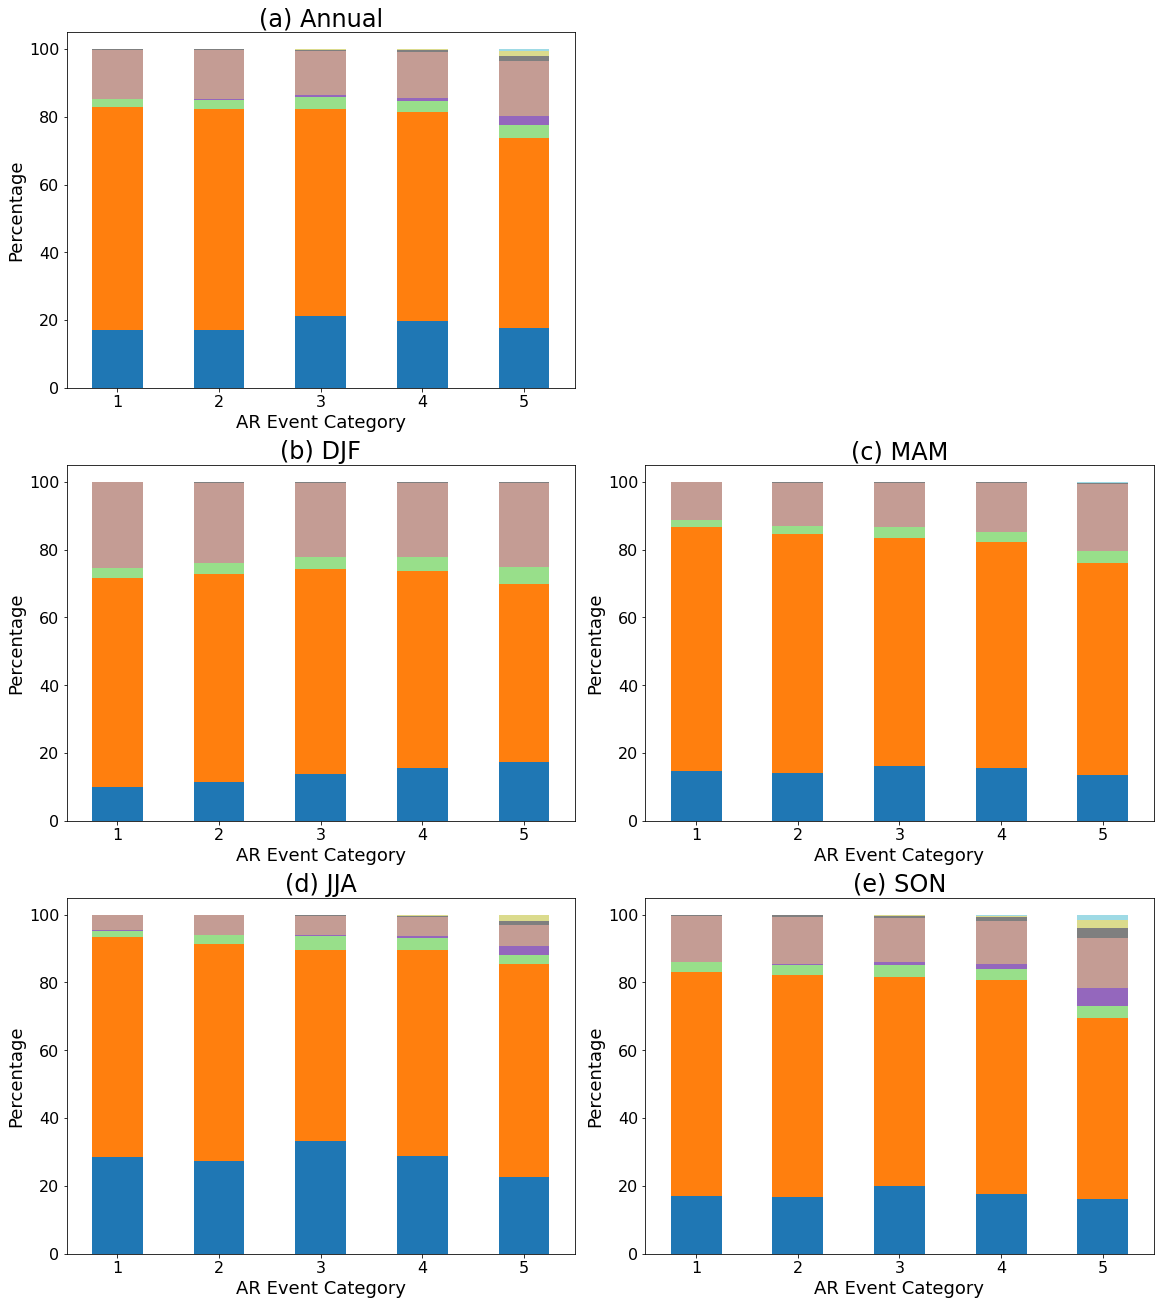

In [27]:
#Final plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# --- Label mapping ---
label_index = {
    1: 'AR', 2: 'Front', 3: 'MCS', 4: 'LPS',
    5: 'AR + Front', 6: 'AR + MCS', 7: 'AR + LPS',
    8: 'Front + MCS', 9: 'Front + LPS',
    10: 'MCS + LPS', 11: 'AR + Front + MCS',
    12: 'AR + Front + LPS', 13: 'AR + MCS + LPS',
    14: 'Front + MCS + LPS', 15: 'All'
}

# --- Seasonal label mapping ---
season_label_map = {
    "Winter": "DJF",
    "Spring": "MAM",
    "Summer": "JJA",
    "Fall": "SON"
}

# ==========================================================
# Read Annual Data
# ==========================================================

annual_df = pd.read_csv("AR_cooccurrence_percentages.csv", index_col=0)
annual_df = annual_df.dropna(how="all")
annual_df = annual_df.apply(pd.to_numeric, errors='coerce')
filtered_annual = annual_df[(annual_df != 0).any(axis=1)]
present_labels = filtered_annual.index.tolist()

# ==========================================================
# Read Seasonal Data
# ==========================================================

result_df = pd.read_csv("results_seasons.csv", index_col=0)
seasons = result_df.index.unique()

# ==========================================================
# Determine which categories actually exist
# ==========================================================

def label_to_index(label):
    return [k for k, v in label_index.items() if v == label][0]

present_ids = {label_to_index(lbl) for lbl in present_labels}

for season in seasons:
    df_season = result_df.loc[season]
    pivot_df = df_season.pivot(index='CoCategory', columns='ARCategory', values='Percent')
    pivot_df = pivot_df.rename(index=label_index)
    pivot_df = pivot_df[(pivot_df != 0).any(axis=1)]
    season_present_labels = pivot_df.index.tolist()
    present_ids.update({label_to_index(lbl) for lbl in season_present_labels})

existing_labels = {i: label_index[i] for i in sorted(present_ids)}

# ==========================================================
# Discrete colormap + norm
# ==========================================================

cmap = plt.get_cmap("tab20", len(existing_labels))
bounds = list(existing_labels.keys()) + [max(existing_labels.keys()) + 1]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

category_colors = {k: cmap(norm(k + 0.5)) for k in existing_labels}

# ==========================================================
# Figure setup (3x2 grid with top-right empty)
# ==========================================================

fig = plt.figure(figsize=(16, 18), constrained_layout=True)
gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1])

# --- Top row: annual plot (left) + empty panel (right) ---
ax_annual = fig.add_subplot(gs[0, 0])
ax_empty = fig.add_subplot(gs[0, 1])
ax_empty.axis('off')  # hide the empty panel

present_colors = [
    category_colors[i] for i, label in label_index.items()
    if label in present_labels and i in category_colors
]

bars = filtered_annual.T.plot(
    kind='bar', stacked=True, ax=ax_annual,
    color=present_colors, legend=False
)

ax_annual.set_xlabel("AR Event Category", fontsize=18)
ax_annual.set_ylabel("Percentage", fontsize=18)
ax_annual.tick_params(axis='both', which='major', labelsize=16)
ax_annual.tick_params(axis='x', labelrotation=0)
ax_annual.set_title("(a) Annual", fontsize=24)

axes_all = [ax_annual]

# ==========================================================
# Seasonal Plots
# ==========================================================

season_positions = [(1, 0), (1, 1), (2, 0), (2, 1)]
season_titles = ['(b) DJF', '(c) MAM', '(d) JJA', '(e) SON']

for season, pos, title in zip(seasons, season_positions, season_titles):

    ax = fig.add_subplot(gs[pos])
    axes_all.append(ax)

    df_season = result_df.loc[season]
    pivot_df = df_season.pivot(index='CoCategory', columns='ARCategory', values='Percent')
    pivot_df = pivot_df.rename(index=label_index)
    pivot_df = pivot_df[(pivot_df != 0).any(axis=1)]

    season_present_labels = pivot_df.index.tolist()

    season_colors = [
        category_colors[i] for i, label in label_index.items()
        if label in season_present_labels and i in category_colors
    ]

    pivot_df.T.plot(
        kind='bar', stacked=True, ax=ax,
        color=season_colors, legend=False
    )

    ax.set_xlabel("AR Event Category", fontsize=18)
    ax.set_ylabel("Percentage", fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.tick_params(axis='x', labelrotation=0)
    ax.set_title(title, fontsize=24)

# ==========================================================
# Common Y-limit
# ==========================================================

ymax = max(ax.get_ylim()[1] for ax in axes_all)
for ax in axes_all:
    ax.set_ylim(0, ymax)

# ==========================================================
# Save
# ==========================================================

plt.savefig("AR_cooccurrence_plots_discrete_cmap_no_legend.svg", dpi=300, bbox_inches='tight')
plt.show()